# Comparative Analysis of Machine Learning Algorithms for Diabetes Risk Prediction Using the DiaBD Bangladesh Dataset

## 1. Project Introduction

**Task:** Binary classification — predict whether a patient is **Diabetic** or **Non-Diabetic** from clinical and demographic measurements.

**Dataset:** DiaBD — A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh (`data/diabd.csv`).

**Algorithms compared:** Logistic Regression, K-Nearest Neighbors (KNN), Random Forest, and XGBoost.

**Why this matters:** The dataset is expected to be — and turns out to be — heavily imbalanced (very few diabetic patients relative to non-diabetic patients). A major goal of this notebook, beyond simply training four models, is to show *why accuracy alone is a misleading metric* on imbalanced medical data, and to compare how each algorithm can be adapted to handle that imbalance.

All code in this notebook calls into the reusable, tested modules in `src/` (`data_preprocessing.py`, `eda.py`, `train_models.py`, `evaluate_models.py`), so the notebook and `python main.py` produce identical, reproducible results (`random_state=42` throughout).

## 2. Imports and Configuration

In [1]:
import sys
import os

# Allow imports from the project's src/ package when running the notebook
# from inside the notebooks/ folder.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import utils  # also registers the benign-warning suppressions (see src/utils.py)
from src import eda
from src import evaluate_models as ev
from src.data_preprocessing import (
    load_data, clean_data, encode_target, split_data, build_preprocessor, get_feature_names,
)
from src.train_models import (
    build_pipelines, build_smote_pipelines, compute_scale_pos_weight, fit_all, tune_all,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
%matplotlib inline

print("Random seed used throughout:", utils.RANDOM_STATE)

Random seed used throughout: 42


## 3. Dataset Loading

In [2]:
df_raw = load_data()
print(f"Loaded dataset from: {utils.DATA_PATH}")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Loaded dataset from: /Users/nazeebahmed/8th semester/ML-8thSem/Ml-assignment/data/diabd.csv
Shape: (5288, 15)


,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


## 4. Dataset Inspection

We inspect the dataset thoroughly before touching it: shape, column types, missing values, duplicates, and summary statistics. This step matters because it tells us exactly what cleaning decisions (Section 5) are actually justified by the data, rather than guessed.

In [3]:
df_raw.tail()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
5283,74,Male,83,164,89,6.47,1.60,64.0,24.99,0,1,0,1,0,No
5284,75,Male,67,141,104,8.31,1.65,62.0,22.75,0,0,0,0,0,Yes
5285,40,Female,67,134,114,7.61,1.50,69.0,30.72,0,1,0,0,1,No
5286,36,Female,62,139,80,4.90,1.52,41.5,17.87,0,0,0,0,0,No
5287,26,Female,80,134,93,5.15,1.47,67.1,30.92,0,0,0,0,0,No


In [4]:
print("Shape (rows, columns):", df_raw.shape)
print("\
Columns:", list(df_raw.columns))
df_raw.info()

Shape (rows, columns): (5288, 15)
Columns: ['age', 'gender', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'height', 'weight', 'bmi', 'family_diabetes', 'hypertensive', 'family_hypertension', 'cardiovascular_disease', 'stroke', 'diabetic']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   object 
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hy

In [5]:
df_raw.describe()

,age,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
count,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000
mean,45.745651,76.626135,133.996596,82.229576,7.563922,1.548886,53.644100,22.466581,0.031959,0.111006,0.033661,0.011346,0.003782
std,13.422024,12.229319,22.231752,12.479007,2.944381,0.080328,10.076059,8.819898,0.175908,0.314169,0.180372,0.105924,0.061389
min,21.000000,5.000000,62.000000,45.000000,0.000000,0.360000,3.000000,1.220000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,69.000000,119.000000,73.000000,6.000000,1.520000,46.775000,19.620000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,45.000000,76.000000,130.000000,81.000000,6.930000,1.550000,53.000000,21.870000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,84.000000,147.000000,90.000000,8.130000,1.600000,59.900000,24.472500,0.000000,0.000000,0.000000,0.000000,0.000000
max,80.000000,133.000000,231.000000,119.000000,33.460000,1.960000,100.700000,574.130000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print("\
Duplicate rows:", df_raw.duplicated().sum())

Missing values per column:
age                       0
gender                    0
pulse_rate                0
systolic_bp               0
diastolic_bp              0
glucose                   0
height                    0
weight                    0
bmi                       0
family_diabetes           0
hypertensive              0
family_hypertension       0
cardiovascular_disease    0
stroke                    0
diabetic                  0
dtype: int64
Duplicate rows: 0


**Result:** no missing values and no duplicate rows anywhere in the raw dataset.

**Numerical features:** `age`, `pulse_rate`, `systolic_bp`, `diastolic_bp`, `glucose`, `height`, `weight`, `bmi`.

**Categorical / binary-flag features:** `gender` (text: Female/Male), and `family_diabetes`, `hypertensive`, `family_hypertension`, `cardiovascular_disease`, `stroke` (already stored as 0/1 integers).

**Target:** `diabetic` (text: Yes/No).

### Target variable inspection

In [7]:
print("Class counts:")
print(df_raw["diabetic"].value_counts())
print("\
Class percentages:")
print((df_raw["diabetic"].value_counts(normalize=True) * 100).round(2))

Class counts:
diabetic
No     4946
Yes     342
Name: count, dtype: int64
Class percentages:
diabetic
No     93.53
Yes     6.47
Name: proportion, dtype: float64


**Finding:** the target is severely imbalanced — only 6.47% of patients (342 of 5,288) are labeled diabetic. This imbalance drives most of the methodological decisions in this project (Sections 7, 15, 16).

### Checking for suspicious / impossible values

Looking at `df_raw.describe()` above, several values look physiologically implausible for a living adult patient: a minimum `glucose` of 0.0, a minimum `height` of 0.36 m, a minimum `pulse_rate` of 5 bpm, and a maximum `bmi` of 574 (since `bmi = weight / height²` in this dataset, an impossibly small height produces an impossibly large BMI). Easy to miss at first glance: the minimum `weight` is just 3.0 kg, for a patient aged 46 in a dataset whose ages range 21-80 — clearly impossible, and *not* caught by the glucose/height/pulse_rate checks alone. That is a reminder to scan every column in `describe()`, not just the ones that jump out first. We check all of these explicitly below, using BMI (which combines height and weight) to catch implausible body-weight/height combinations directly rather than guessing a raw weight cutoff.

In [8]:
print("Rows with glucose == 0:", (df_raw["glucose"] == 0).sum())
print("Rows with height < 1.2 m (adult):", (df_raw["height"] < 1.2).sum())
print("Rows with pulse_rate < 30 bpm:", (df_raw["pulse_rate"] < 30).sum())
print("Rows with bmi < 10 (adult):", (df_raw["bmi"] < 10).sum())
print("Rows with bmi > 70 (adult):", (df_raw["bmi"] > 70).sum())
print()
impossible_mask = (
    (df_raw["glucose"] == 0)
    | (df_raw["height"] < 1.2)
    | (df_raw["pulse_rate"] < 30)
    | (df_raw["bmi"] < 10)
    | (df_raw["bmi"] > 70)
)
print(f"Total distinct rows flagged as physiologically impossible: {impossible_mask.sum()}")
df_raw.loc[impossible_mask, ["age", "gender", "glucose", "height", "weight", "bmi", "pulse_rate", "diabetic"]]

Rows with glucose == 0: 1
Rows with height < 1.2 m (adult): 6
Rows with pulse_rate < 30 bpm: 3
Rows with bmi < 10 (adult): 2
Rows with bmi > 70 (adult): 2

Total distinct rows flagged as physiologically impossible: 12


,age,gender,glucose,height,weight,bmi,pulse_rate,diabetic
152,24,Male,4.89,0.36,72.6,574.13,63,No
885,75,Female,7.24,0.64,62.8,155.74,71,No
1138,28,Female,0.00,1.52,55.0,23.81,98,No
1279,46,Female,12.00,1.57,3.0,1.22,104,No
1731,70,Male,10.43,1.63,21.9,8.29,65,No
3631,50,Female,15.00,1.19,55.0,38.84,81,No
3632,50,Female,5.00,1.19,55.0,38.84,80,No
3636,63,Female,15.00,1.19,60.0,42.37,72,Yes
4013,38,Female,6.00,0.99,23.0,23.47,72,No
4812,70,Female,25.00,1.60,58.0,22.66,5,No


## 5. Data Cleaning

We remove exactly these 12 rows — they are physiologically impossible measurements (data-entry errors), not natural statistical outliers. Three simple univariate checks (`glucose == 0`, `height < 1.0 m`, `pulse_rate < 30`) only caught 7 of them; widening the height threshold to `< 1.2 m` and adding a BMI-based check (`bmi < 10` or `bmi > 70`) caught 5 more — including a 3 kg adult (bmi 1.22), a 21.9 kg adult (bmi 8.29), and three separate rows sharing an identical, implausible 1.19 m / 55-60 kg pattern that looks like a repeated data-entry error rather than a genuine short-stature cohort. This is a **targeted, documented** removal, not a blanket outlier-removal step: plausible-but-extreme values (e.g. very high glucose in a poorly-controlled diabetic) are deliberately kept and analyzed in Section 6 instead. `clean_data()` (in `src/data_preprocessing.py`) also checks for duplicate rows.

In [9]:
df_clean = clean_data(df_raw, verbose=True)

Rows before cleaning: 5288
Rows removed (impossible values): 12
Duplicate rows removed: 0
Rows after cleaning: 5276


## 6. Exploratory Data Analysis

We use a copy of the cleaned data with a readable target column (`diabetic_label`) purely for plot legends.

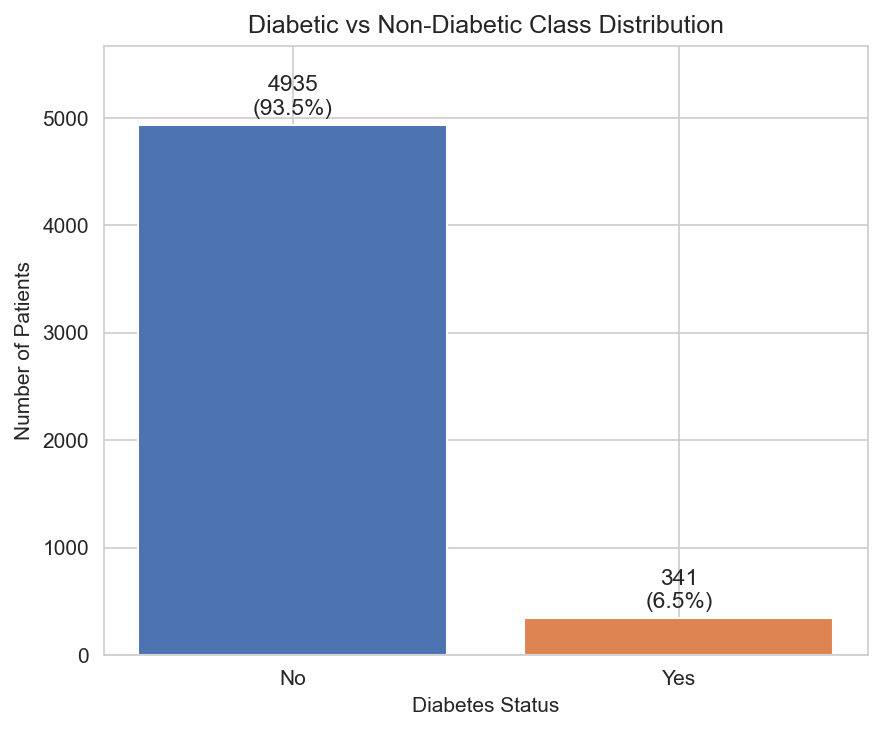

In [10]:
from IPython.display import Image, display

# Each eda.* function saves its figure to outputs/figures/ AND returns the file path.
# We display that saved file inline so the notebook and outputs/figures/ always match exactly.
df_eda = df_clean.rename(columns={"diabetic": "diabetic_label"})
path = eda.plot_class_distribution(df_eda)
display(Image(path))

### Numerical features: distribution and diabetic vs. non-diabetic comparison

For each key numerical variable we plot a histogram (overall distribution) and a class-wise boxplot side by side.

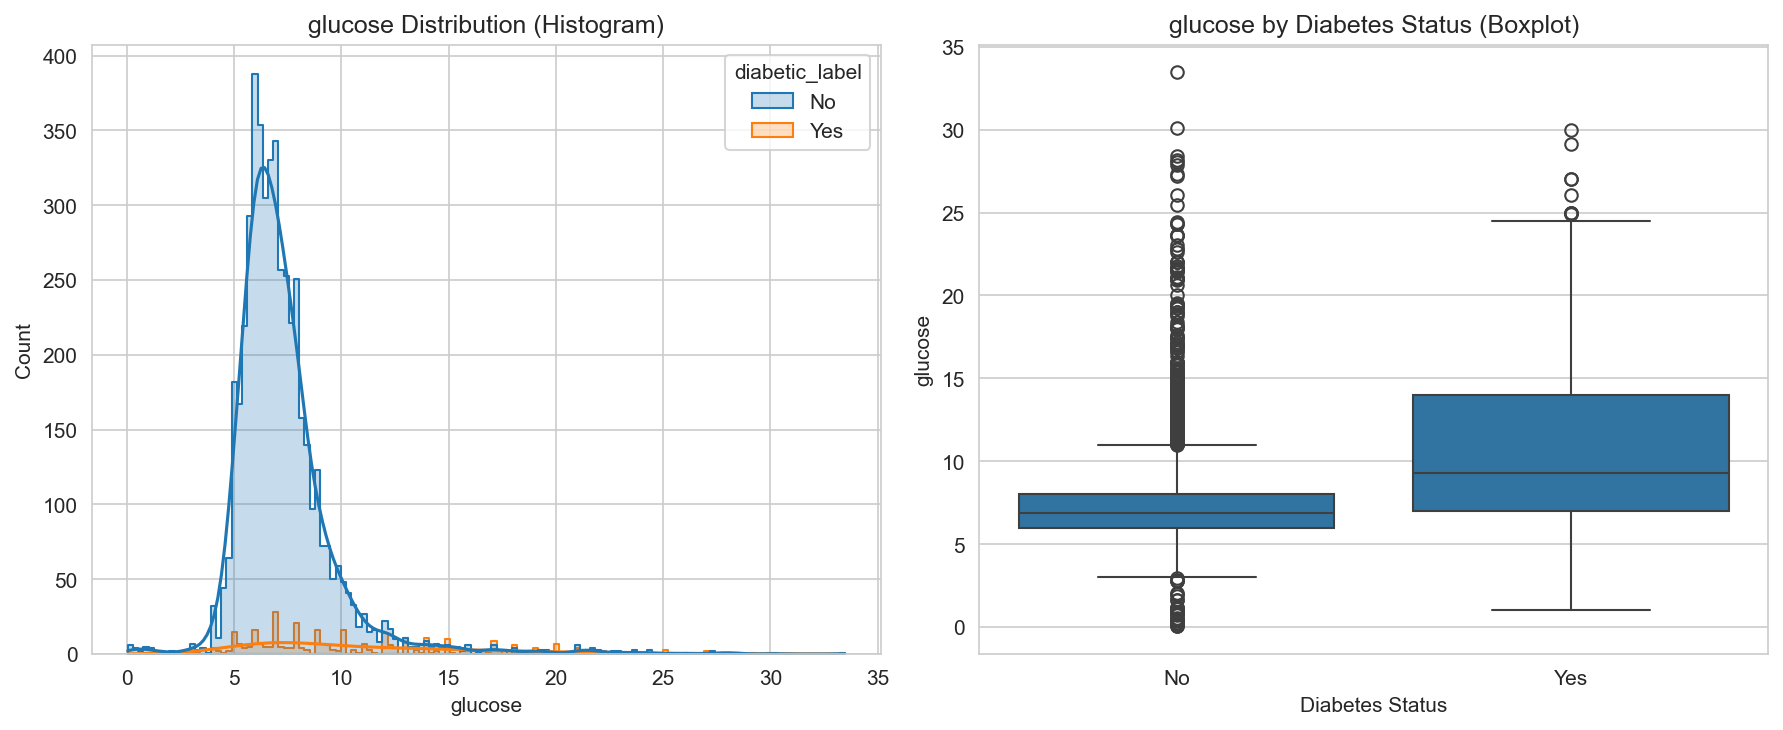

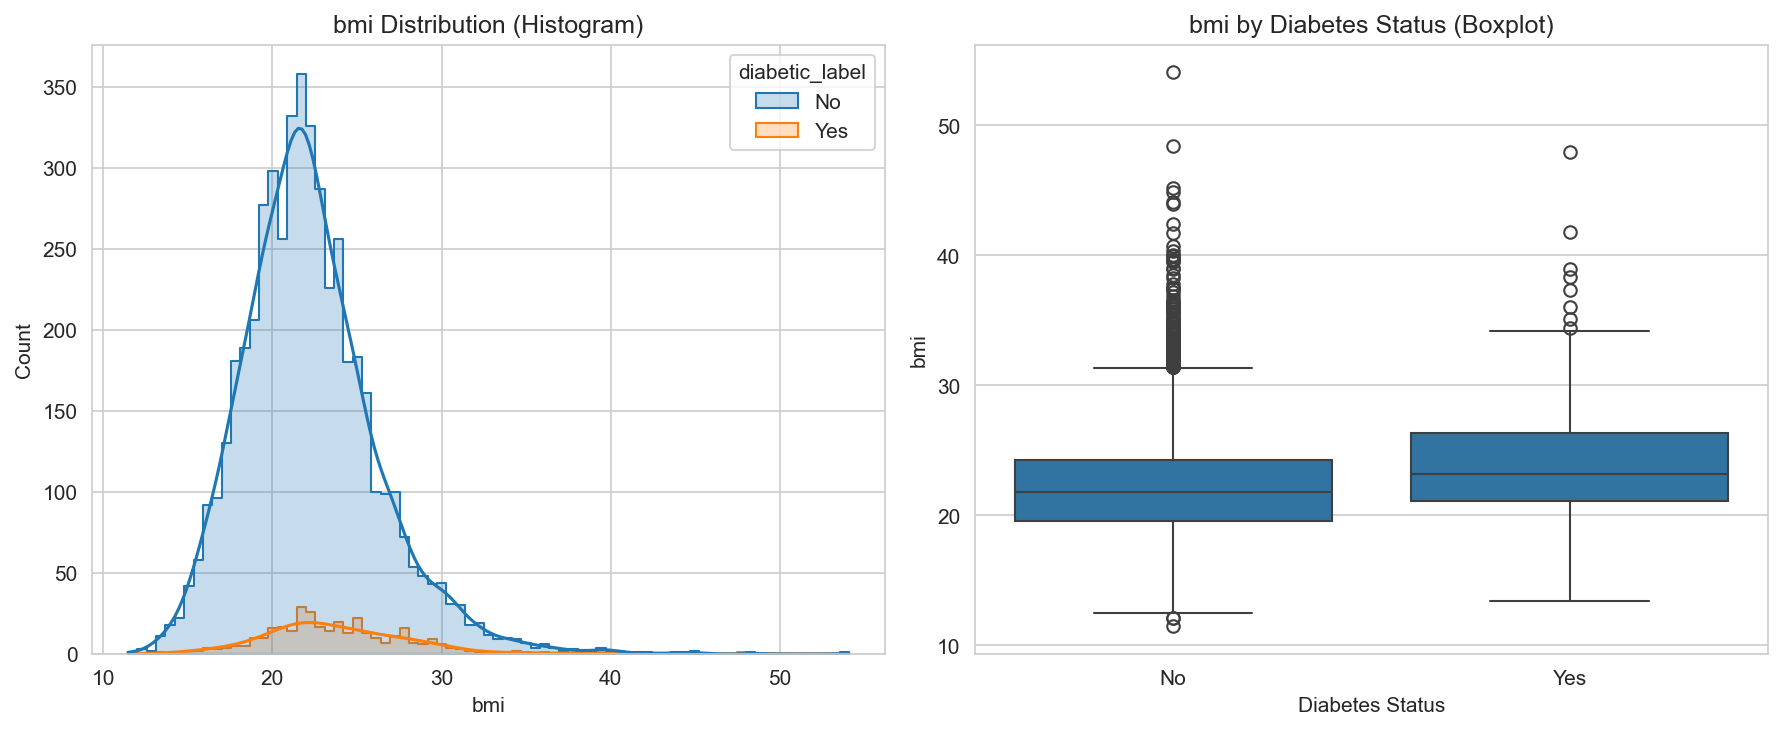

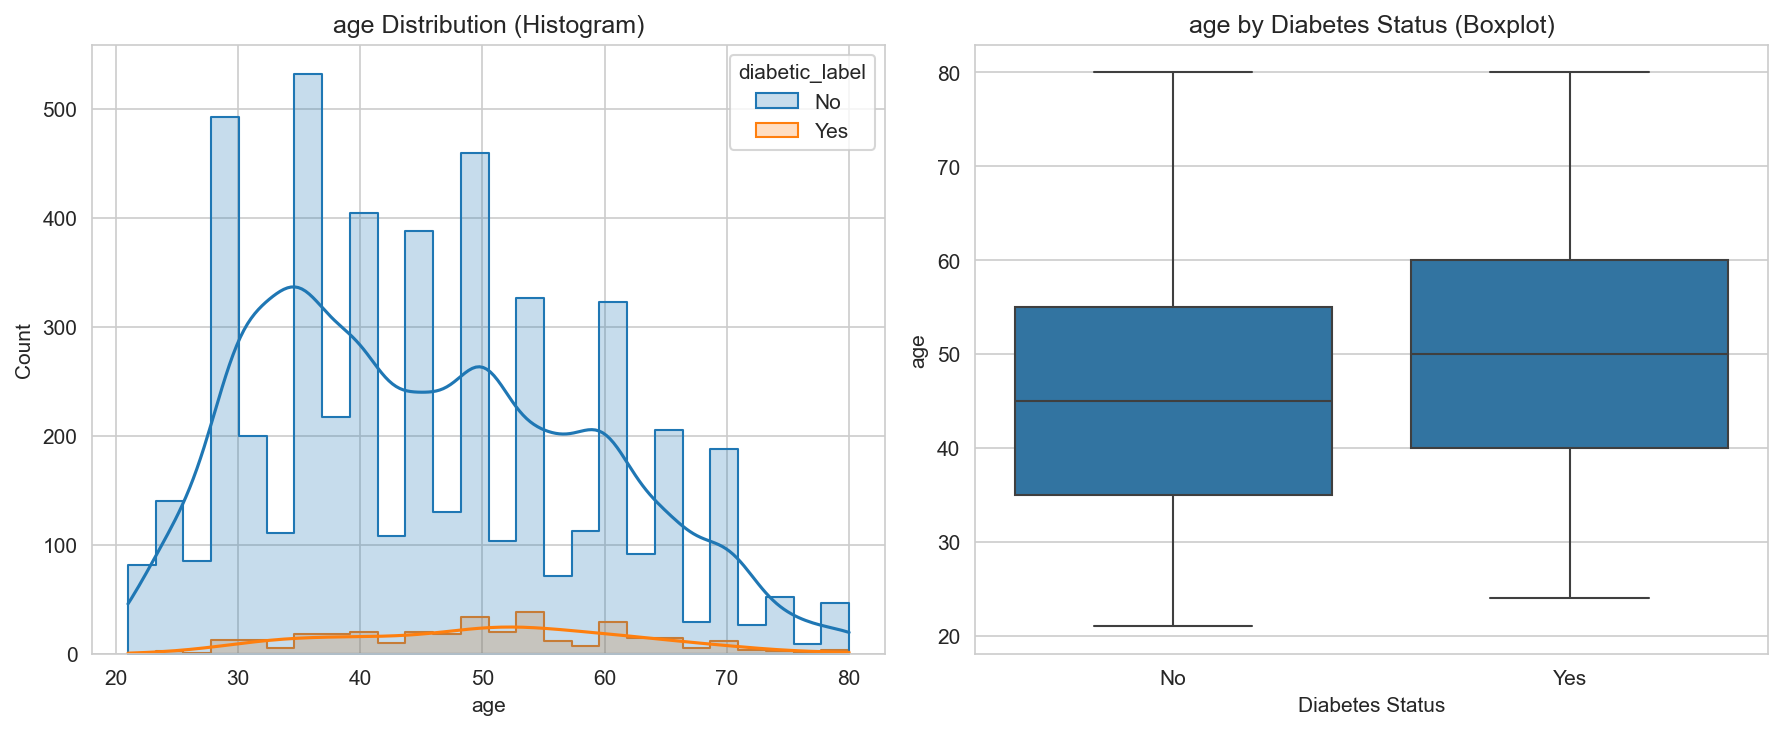

In [11]:
for col in ["glucose", "bmi", "age"]:
    display(Image(eda.plot_numeric_distribution(df_eda, col)))

In [12]:
print("Median glucose by diabetes status:")
print(df_clean.groupby("diabetic")["glucose"].median())
print("\
Median BMI by diabetes status:")
print(df_clean.groupby("diabetic")["bmi"].median())
print("\
Median age by diabetes status:")
print(df_clean.groupby("diabetic")["age"].median())

Median glucose by diabetes status:
diabetic
No     6.85
Yes    9.28
Name: glucose, dtype: float64
Median BMI by diabetes status:
diabetic
No     21.79
Yes    23.19
Name: bmi, dtype: float64
Median age by diabetes status:
diabetic
No     45.0
Yes    50.0
Name: age, dtype: float64


**Finding:** median glucose is clearly higher for diabetic patients (9.28 vs 6.85 mmol/L) — the expected and strongest separation of any numerical feature. BMI (23.19 vs 21.79) and age (50 vs 45) show smaller, but still directionally expected, differences.

The remaining numerical features (blood pressure, pulse rate, weight, height) are also plotted and saved to `outputs/figures/` by `main.py`; we don't repeat all of them inline here to keep the notebook focused, but they follow the same `eda.plot_numeric_distribution(df_eda, column)` pattern.

### Categorical / binary features vs. target

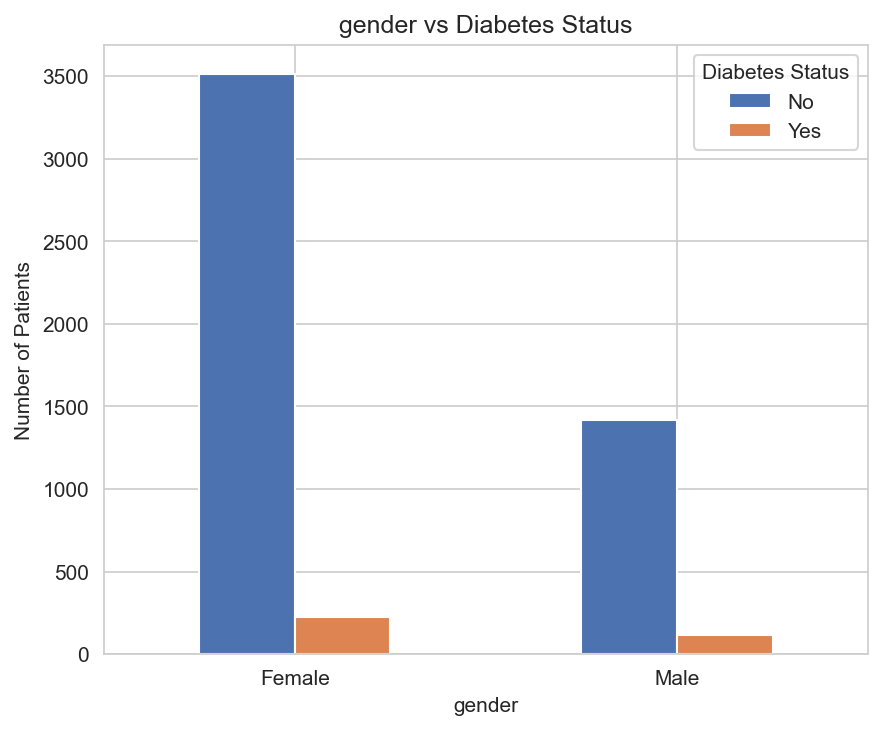

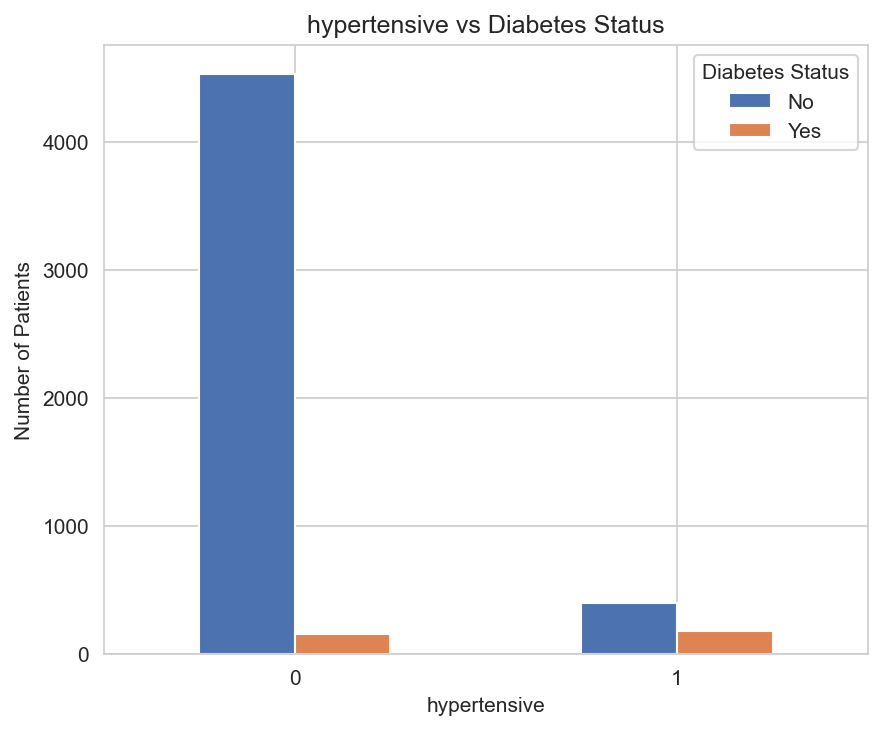

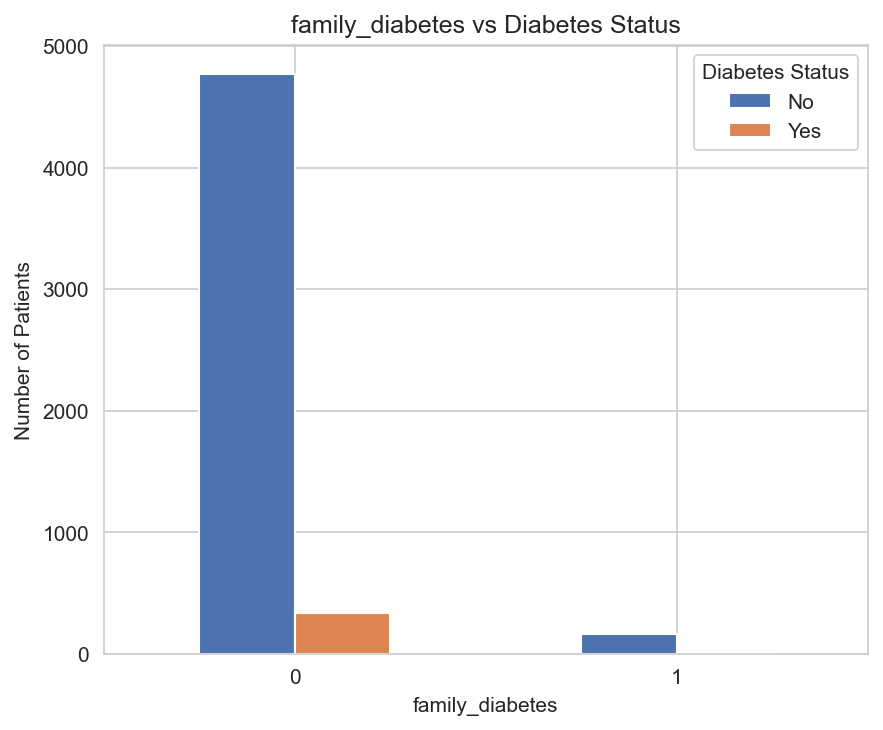

Diabetes prevalence by hypertension status (%):
diabetic         No    Yes
hypertensive              
0             96.63   3.37
1             68.72  31.28


In [13]:
for col in ["gender", "hypertensive", "family_diabetes"]:
    display(Image(eda.plot_categorical_vs_target(df_eda, col)))

print("Diabetes prevalence by hypertension status (%):")
print((df_clean.groupby("hypertensive")["diabetic"].value_counts(normalize=True).unstack() * 100).round(2))

**Finding:** hypertension status shows a dramatic relationship with diabetes — 31.3% of hypertensive patients are diabetic vs. only 3.4% of non-hypertensive patients (roughly a 9x difference). This is the strongest categorical association in the dataset and, as we will see in Section 22 (Feature Importance), it is picked up as one of the top two most influential features by every model (rank #1 for two of the three interpretable models, rank #2 for the third). Gender shows only a small difference (6.1% female vs 7.4% male). The `family_diabetes=1` subgroup is small (169 patients) and shows a lower rate than expected — likely a sampling artifact given the small subgroup size, not a reliable population-level pattern (see Limitations, Section 24).

### Correlation heatmap (numerical features only)

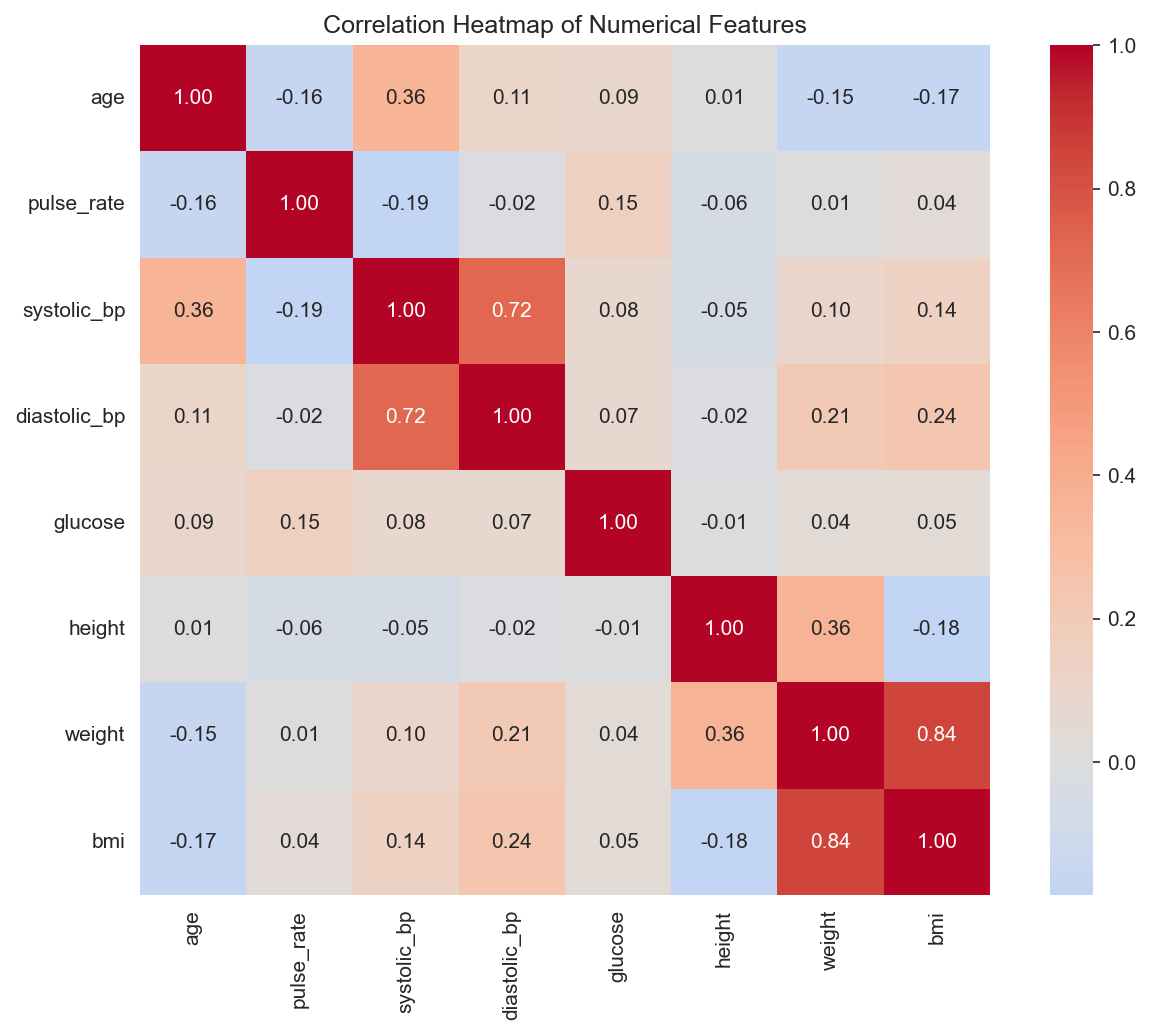

In [14]:
display(Image(eda.plot_correlation_heatmap(df_clean)))

**Finding:** the strongest correlations are `weight`-`bmi` (r=0.84, expected since BMI is computed from weight and height) and `systolic_bp`-`diastolic_bp` (r=0.72, expected physiologically). `glucose` is only weakly correlated with the other numerical features (|r|<0.16), suggesting it carries mostly independent predictive signal.

### Outlier analysis

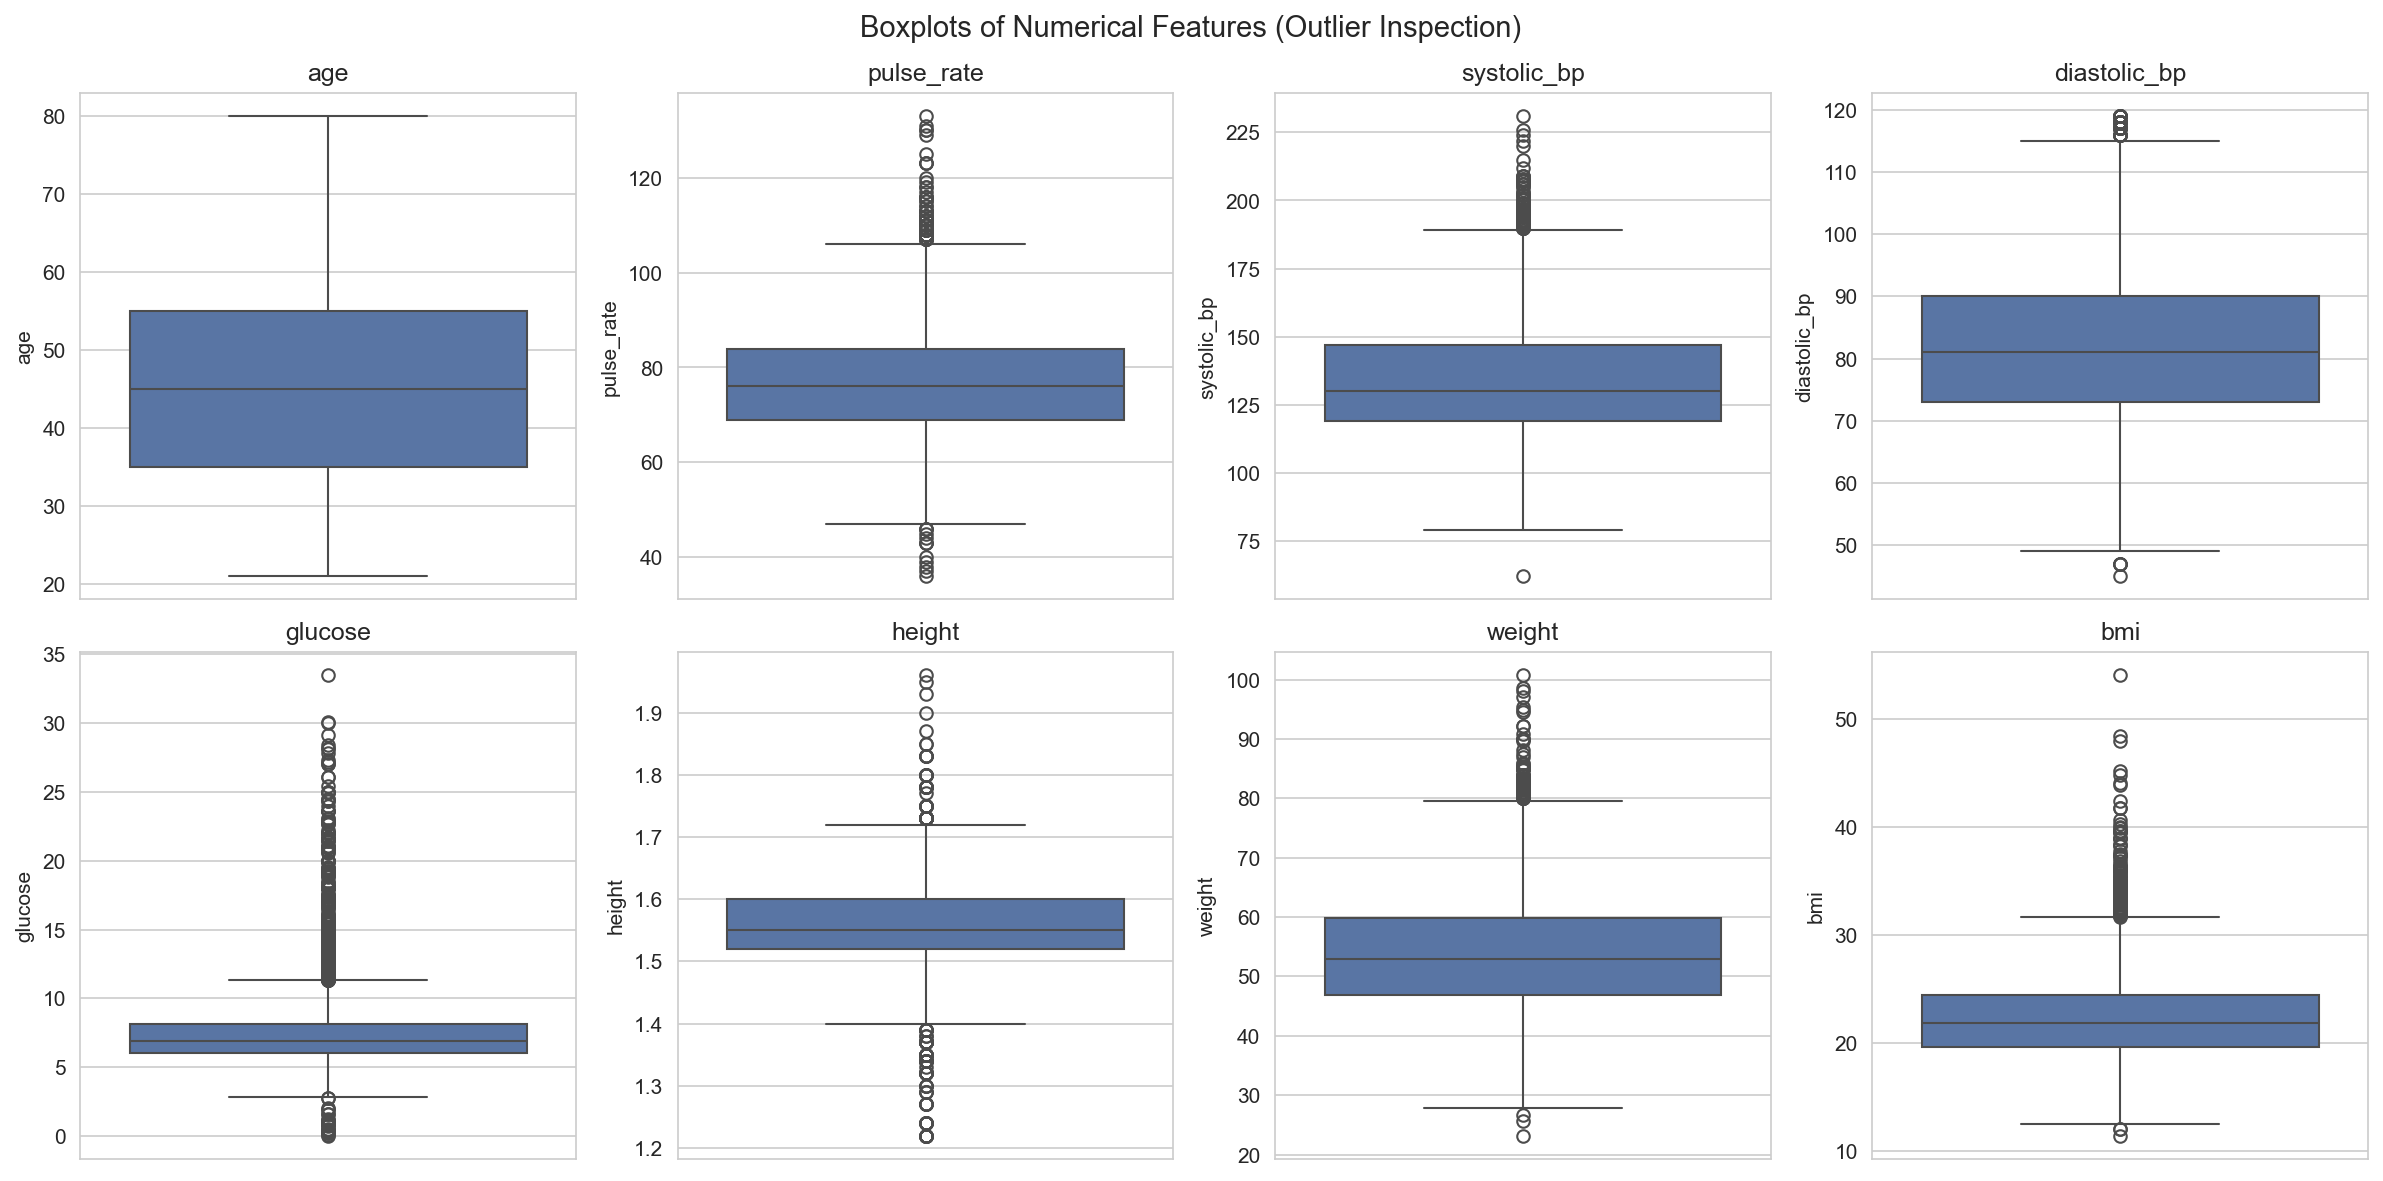

In [15]:
display(Image(eda.plot_boxplots_outliers(df_clean)))

**Decision:** several numerical features (e.g. `glucose`, `systolic_bp`) show statistical outliers above the boxplot whiskers. These were deliberately **retained** — a glucose reading of ~30 mmol/L is very high but medically plausible for a poorly-controlled diabetic patient, and removing such points would bias the model against exactly the cases we want it to learn to detect. Only the physiologically *impossible* values identified and removed in Section 5 were treated as data errors.

## 7. Target / Class Imbalance Analysis

In [16]:
counts = df_clean["diabetic"].value_counts()
percentages = df_clean["diabetic"].value_counts(normalize=True) * 100
print("Cleaned dataset class counts:")
print(counts)
print("\
Cleaned dataset class percentages:")
print(percentages.round(2))
print(f"\
Imbalance ratio (non-diabetic : diabetic) = {counts['No'] / counts['Yes']:.1f} : 1")

Cleaned dataset class counts:
diabetic
No     4935
Yes     341
Name: count, dtype: int64
Cleaned dataset class percentages:
diabetic
No     93.54
Yes     6.46
Name: proportion, dtype: float64
Imbalance ratio (non-diabetic : diabetic) = 14.5 : 1


**Why this matters:** a classifier that always predicts "non-diabetic" would score about 93.5% accuracy while catching **zero** true diabetic patients. This is why accuracy alone is not used to judge the models in this notebook — we rely on recall, F1-score, and ROC-AUC instead (Section 15 explains why), and we explicitly compare imbalance-handling strategies (class weighting and SMOTE) in Section 16.

## 8. Train-Test Split

In [17]:
df_model = encode_target(df_clean)  # "diabetic": Yes/No -> 1/0
X_train, X_test, y_train, y_test = split_data(df_model)  # 80/20, stratified, random_state=42

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print("\
Train class distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\
Test class distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train: (4220, 14), X_test: (1056, 14)
Train class distribution (%):
diabetic
0    93.53
1     6.47
Name: proportion, dtype: float64
Test class distribution (%):
diabetic
0    93.56
1     6.44
Name: proportion, dtype: float64


**Note:** stratification kept the train and test class ratios almost identical to the original (93.5% / 6.5%), as intended. **The test set is now set aside and is not touched again until Section 19 (Final Model Evaluation).**

## 9. Preprocessing Pipelines

We build a `ColumnTransformer` (`src/data_preprocessing.py::build_preprocessor`) that:
- applies `StandardScaler` to the 8 numerical features (only when `scale_numeric=True`),
- one-hot encodes `gender`,
- passes the 5 already-binary flag columns through unchanged.

**Why scaling matters for Logistic Regression and KNN but not for Random Forest/XGBoost:** Logistic Regression's coefficients and KNN's distance calculations are both sensitive to the *scale* of each feature — without scaling, a feature like `systolic_bp` (range ~60-230) would dominate a feature like `bmi` (range ~15-45) purely because of its larger numeric range, not because it is more informative. Tree-based models (Random Forest, XGBoost) split on individual feature thresholds (e.g. "is glucose > 7.2?"), and the threshold search is unaffected by monotonic rescaling — so scaling is unnecessary for them.

**Preventing leakage:** the `ColumnTransformer` is always placed as the first step inside an `sklearn.Pipeline` alongside its classifier, and is only ever `.fit()` on `X_train` — so the scaler's mean/std and the one-hot categories are learned strictly from training data. The same applies to SMOTE (Section 17) and hyperparameter search (Section 18), which only ever see training folds. See the report, Section 22, for the explicit leakage checklist.

In [18]:
preprocessor_demo = build_preprocessor(scale_numeric=True)
preprocessor_demo.fit(X_train)  # fit on TRAINING data only
print("Transformed feature names:")
print(get_feature_names(preprocessor_demo))

Transformed feature names:
['num__age', 'num__pulse_rate', 'num__systolic_bp', 'num__diastolic_bp', 'num__glucose', 'num__height', 'num__weight', 'num__bmi', 'gender__gender_Male', 'flags__family_diabetes', 'flags__hypertensive', 'flags__family_hypertension', 'flags__cardiovascular_disease', 'flags__stroke']


## 10-13. Baseline Models (No Imbalance Handling)

We first train all four models on the **original imbalanced training data**, with no class weighting and no SMOTE, using reasonable default hyperparameters (`src/train_models.py::build_pipelines`). This baseline is essential: it is what motivates the imbalance-handling work in Section 16, and it is what we compare tuned results against in Section 18.

- **Logistic Regression:** default regularization strength, `solver="liblinear"` (chosen for numerical stability on this dataset — see code comments in `src/train_models.py`).
- **KNN:** `n_neighbors=5` (a common default).
- **Random Forest:** `n_estimators=200`, `random_state=42`.
- **XGBoost:** `objective="binary:logistic"`, `random_state=42`.

In [19]:
baseline_pipelines = build_pipelines()
baseline_fitted = fit_all(baseline_pipelines, X_train, y_train)
print("Fitted models:", list(baseline_fitted.keys()))

Fitted models: ['Logistic Regression', 'KNN', 'Random Forest', 'XGBoost']


## 14. Baseline Model Comparison

In [20]:
baseline_results = ev.build_comparison_table(baseline_fitted, X_test, y_test)
baseline_results.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9384,0.5600,0.2059,0.3011,0.8448
KNN,0.9403,0.6667,0.1471,0.2410,0.7031
Random Forest,0.9384,0.5789,0.1618,0.2529,0.8694
XGBoost,0.9394,0.5526,0.3088,0.3962,0.8761


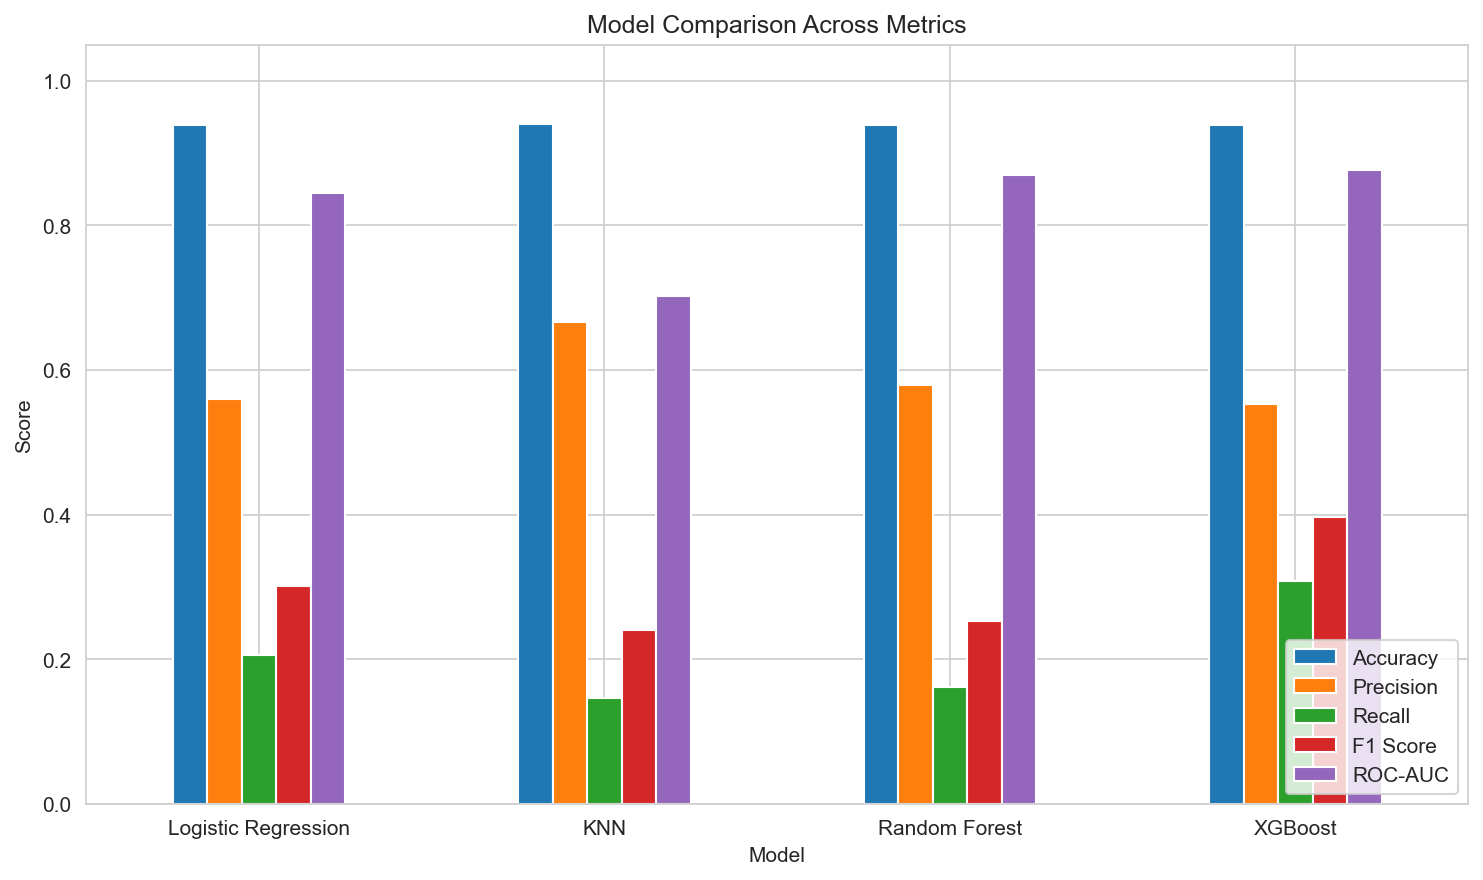

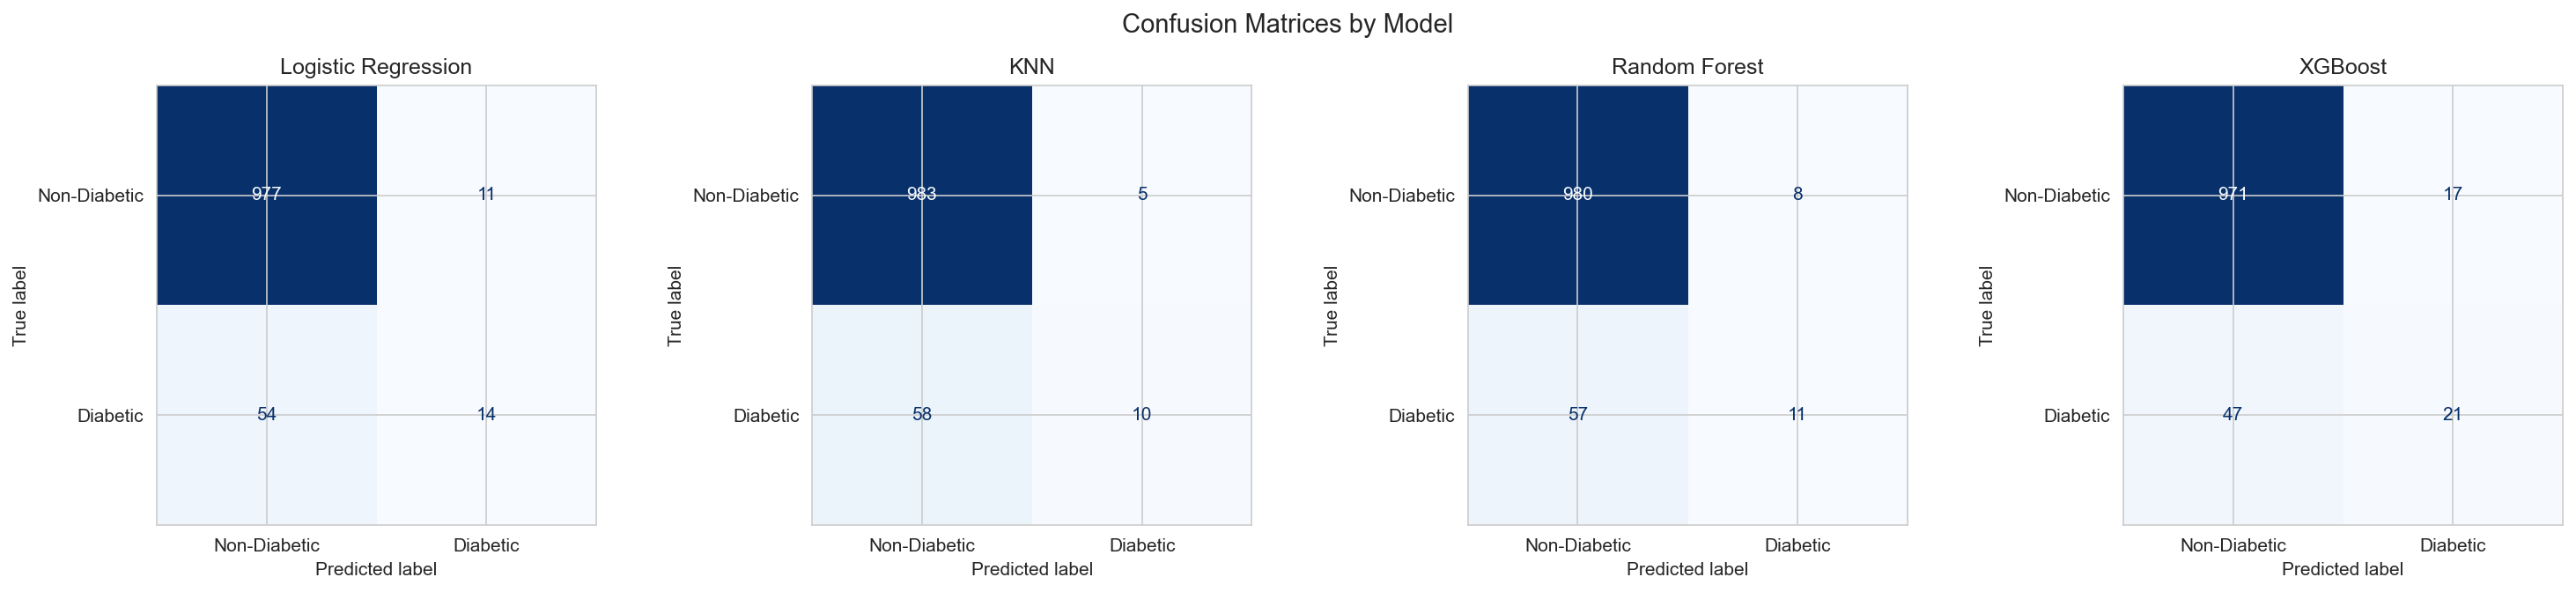

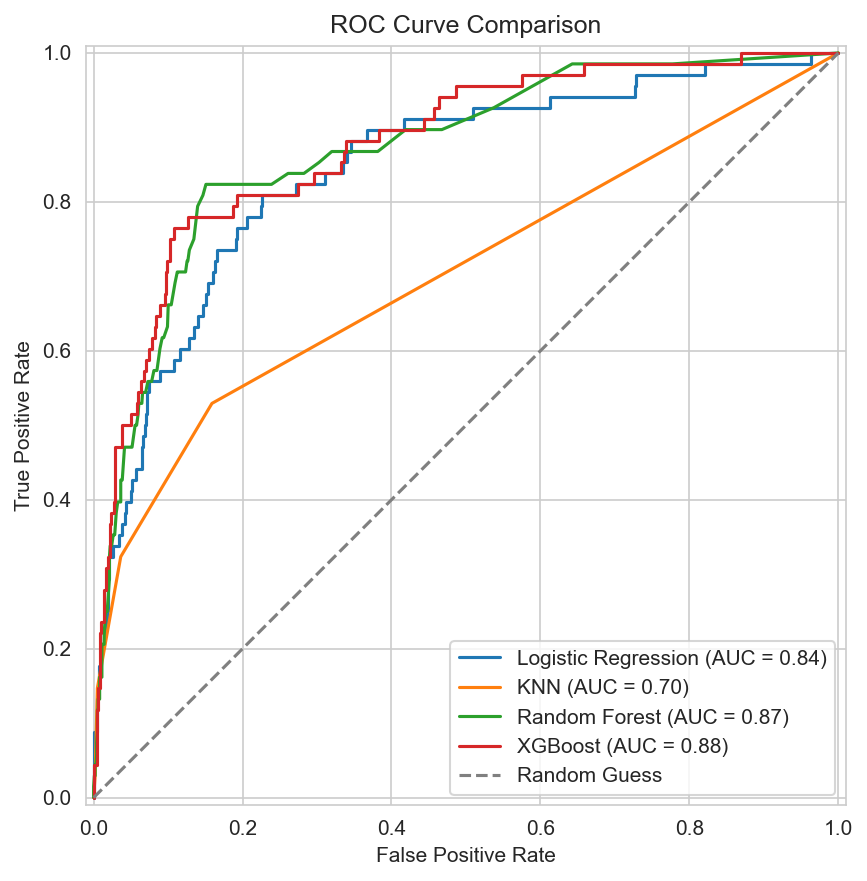

In [21]:
display(Image(ev.plot_model_comparison_bar(baseline_results, filename="model_comparison_baseline.png")))
display(Image(ev.plot_confusion_matrices(baseline_fitted, X_test, y_test, filename="confusion_matrices_baseline.png")))
display(Image(ev.plot_roc_curves(baseline_fitted, X_test, y_test, filename="roc_curves_baseline.png")))

**Key finding:** all four baseline models score within 0.2 points of each other on accuracy (93.84%-94.03%), yet diabetic-class recall ranges from a modest **14.7% (KNN)** to **30.9% (XGBoost)**. This is the clearest demonstration in this notebook of why accuracy alone is an unreliable metric here — every model looks similarly "good" on accuracy while three of the four models still miss at least three-quarters of actual diabetic patients.

## 15. Evaluation Metric Discussion

- **Accuracy** = (TP+TN)/(TP+TN+FP+FN) — misleading here, as shown above.
- **Precision** = TP/(TP+FP) — of patients predicted diabetic, how many actually are.
- **Recall** = TP/(TP+FN) — of patients who are actually diabetic, how many the model catches. **This is the metric we care about most for screening:** a false negative (missed diabetic patient) delays diagnosis, which is generally more costly than a false positive (an unnecessary follow-up test).
- **F1-score** = 2×(Precision×Recall)/(Precision+Recall) — balances the two; used as our hyperparameter-tuning objective (Section 18).
- **ROC-AUC** — probability the model ranks a random diabetic patient's risk higher than a random non-diabetic patient's; threshold-independent, useful for judging overall ranking quality.

## 16. Class Imbalance Handling

**Strategy A: class weighting.** `class_weight="balanced"` for Logistic Regression and Random Forest; a computed `scale_pos_weight` (= n_negative/n_positive on the training set) for XGBoost. KNN has no equivalent option in scikit-learn, so it is left unweighted here (we do not force an invalid approach onto it) — SMOTE (below) is its imbalance-handling option instead.

In [22]:
scale_pos_weight_value = compute_scale_pos_weight(y_train)
print(f"Computed XGBoost scale_pos_weight (n_negative/n_positive) from TRAINING data: {scale_pos_weight_value:.3f}")

weighted_pipelines = build_pipelines(class_weight="balanced", scale_pos_weight=scale_pos_weight_value)
weighted_fitted = fit_all(weighted_pipelines, X_train, y_train)
weighted_results = ev.build_comparison_table(weighted_fitted, X_test, y_test)
weighted_results.round(4)

Computed XGBoost scale_pos_weight (n_negative/n_positive) from TRAINING data: 14.458


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8305,0.2239,0.6618,0.3346,0.8426
KNN,0.9403,0.6667,0.1471,0.2410,0.7031
Random Forest,0.9337,0.4444,0.1176,0.1860,0.8662
XGBoost,0.9347,0.4915,0.4265,0.4567,0.8642


## 17. SMOTE Experiments

**Strategy B: SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic diabetic-class samples by interpolating between existing diabetic patients' neighbors in feature space. Critically, SMOTE is applied **only to the training fold**, using an `imblearn.pipeline.Pipeline` — the correct flow is:

```
Original Dataset -> Train/Test Split -> Training Set -> SMOTE -> Train Model
                                      -> Untouched Test Set -> Evaluation
```

SMOTE is never applied to the test set — `build_smote_pipelines()` places `SMOTE()` as a pipeline step, so it only resamples data that flows through `.fit()`, never `.predict()`.

In [23]:
smote_pipelines = build_smote_pipelines()
smote_fitted = fit_all(smote_pipelines, X_train, y_train)
smote_results = ev.build_comparison_table(smote_fitted, X_test, y_test)
smote_results.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8333,0.2216,0.6324,0.3282,0.8396
KNN,0.8277,0.1968,0.5441,0.2891,0.7682
Random Forest,0.9271,0.4182,0.3382,0.3740,0.8445
XGBoost,0.9375,0.5208,0.3676,0.4310,0.8513


In [24]:
baseline_labeled = baseline_results.copy(); baseline_labeled.index = [f"{n} (Baseline)" for n in baseline_labeled.index]
weighted_labeled = weighted_results.copy(); weighted_labeled.index = [f"{n} (Class-Weighted)" for n in weighted_labeled.index]
smote_labeled = smote_results.copy(); smote_labeled.index = [f"{n} (SMOTE)" for n in smote_labeled.index]

balanced_results = pd.concat([baseline_labeled, weighted_labeled, smote_labeled])
balanced_results.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression (Baseline),0.9384,0.5600,0.2059,0.3011,0.8448
KNN (Baseline),0.9403,0.6667,0.1471,0.2410,0.7031
Random Forest (Baseline),0.9384,0.5789,0.1618,0.2529,0.8694
XGBoost (Baseline),0.9394,0.5526,0.3088,0.3962,0.8761
Logistic Regression (Class-Weighted),0.8305,0.2239,0.6618,0.3346,0.8426
KNN (Class-Weighted),0.9403,0.6667,0.1471,0.2410,0.7031
Random Forest (Class-Weighted),0.9337,0.4444,0.1176,0.1860,0.8662
XGBoost (Class-Weighted),0.9347,0.4915,0.4265,0.4567,0.8642
Logistic Regression (SMOTE),0.8333,0.2216,0.6324,0.3282,0.8396
KNN (SMOTE),0.8277,0.1968,0.5441,0.2891,0.7682


**Key findings:**
- **Class weighting transformed Logistic Regression** (recall 20.6% -> 66.2%, F1 0.301 -> 0.335) but actually *reduced* Random Forest's recall (16.2% -> 11.8%, F1 0.253 -> 0.186) — `class_weight="balanced"` alone was not just insufficient for Random Forest, it hurt; joint tuning of its other hyperparameters (Section 18) is what actually helps (see Section 19).
- **SMOTE improved recall for every model**, most dramatically for KNN (14.7% -> 54.4%) — confirming a meaningful part of KNN's weak baseline recall was an imbalance problem: with synthetic minority neighbors available, KNN can now actually find diabetic neighbors near a diabetic query point.
- **Every strategy trades accuracy for recall** in most cases — expected and desired, since accuracy was uninformatively high to begin with. Random Forest's class-weighted result is the exception that proves the rule: it lost on both accuracy (93.8% -> 93.4%) *and* recall (16.2% -> 11.8%) at once, a reminder that `class_weight="balanced"` is not automatically beneficial on its own.

## 18. Hyperparameter Tuning

We tune all four models with 5-fold `StratifiedKFold` cross-validation (`random_state=42`), scored on **F1-score** for the diabetic class. F1 is chosen over accuracy (misleading here, as shown), over recall alone (can be "gamed" by predicting positive too liberally), and over ROC-AUC alone (threshold-independent, can look good even when the model's actual thresholded predictions are poorly balanced) — F1 forces a balance between catching diabetic cases and not overwhelming clinicians with false alarms.

`class_weight`/`scale_pos_weight` are included as **tunable** search options for Logistic Regression, Random Forest, and XGBoost, so cross-validation itself decides whether imbalance-aware weighting helps, rather than us assuming it. Logistic Regression and KNN use exhaustive `GridSearchCV` (small search spaces); Random Forest and XGBoost use `RandomizedSearchCV` (`n_iter=30`, larger search spaces) to keep runtime reasonable on a normal laptop.

In [25]:
%%time
searches = tune_all(X_train, y_train, n_iter=30)

tuned_fitted = {}
best_params_rows = []
for name, search in searches.items():
    print(f"\
{name}:")
    print(f"  Best CV F1 score: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    tuned_fitted[name] = search.best_estimator_
    best_params_rows.append({"Model": name, "Best_CV_F1": search.best_score_, "Best_Params": str(search.best_params_)})

best_params_df = pd.DataFrame(best_params_rows).set_index("Model")

Logistic Regression:
  Best CV F1 score: 0.3726
  Best params: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1'}
KNN:
  Best CV F1 score: 0.2806
  Best params: {'classifier__n_neighbors': 3, 'classifier__p': 2, 'classifier__weights': 'distance'}
Random Forest:
  Best CV F1 score: 0.4388
  Best params: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 30, 'classifier__class_weight': 'balanced'}
XGBoost:
  Best CV F1 score: 0.4148
  Best params: {'classifier__subsample': 0.7, 'classifier__scale_pos_weight': 1, 'classifier__n_estimators': 200, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}
CPU times: user 972 ms, sys: 582 ms, total: 1.55 s
Wall time: 11.2 s


**Notable result:** cross-validation *independently* selected `class_weight="balanced"` for both Logistic Regression and Random Forest — the search was free to keep these two models unweighted if that scored better on F1, and it did not, which is evidence, not an assumption, that imbalance-aware weighting helps them on this dataset. XGBoost is the interesting exception: the search instead selected `scale_pos_weight=1` (no weighting at all), leaning on `subsample`/`colsample_bytree`/a lower `learning_rate` instead. This doesn't mean weighting never helps XGBoost — Section 16 showed a hand-picked `scale_pos_weight=14.458` achieved F1=0.457, the single highest F1 of any configuration in this whole notebook, tuned models included — it means this particular 30-iteration `RandomizedSearchCV` search didn't land on that region of the joint hyperparameter space. See Section 23 for more on this.

## 19. Final Model Evaluation

We now evaluate the four **tuned** models on the untouched test set, one time only.

In [26]:
tuned_results = ev.build_comparison_table(tuned_fitted, X_test, y_test)
tuned_results.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8305,0.2239,0.6618,0.3346,0.8427
KNN,0.9299,0.3929,0.1618,0.2292,0.6722
Random Forest,0.9271,0.4286,0.3971,0.4122,0.8675
XGBoost,0.9375,0.5312,0.2500,0.3400,0.8813


In [27]:
ev.print_classification_reports(tuned_fitted, X_test, y_test)


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

Non-Diabetic       0.97      0.84      0.90       988
    Diabetic       0.22      0.66      0.33        68

    accuracy                           0.83      1056
   macro avg       0.60      0.75      0.62      1056
weighted avg       0.92      0.83      0.87      1056


--- Classification Report: KNN ---
              precision    recall  f1-score   support

Non-Diabetic       0.94      0.98      0.96       988
    Diabetic       0.39      0.16      0.23        68

    accuracy                           0.93      1056
   macro avg       0.67      0.57      0.60      1056
weighted avg       0.91      0.93      0.92      1056


--- Classification Report: Random Forest ---
              precision    recall  f1-score   support

Non-Diabetic       0.96      0.96      0.96       988
    Diabetic       0.43      0.40      0.41        68

    accuracy                           0.93     

## 20. ROC Curve Comparison

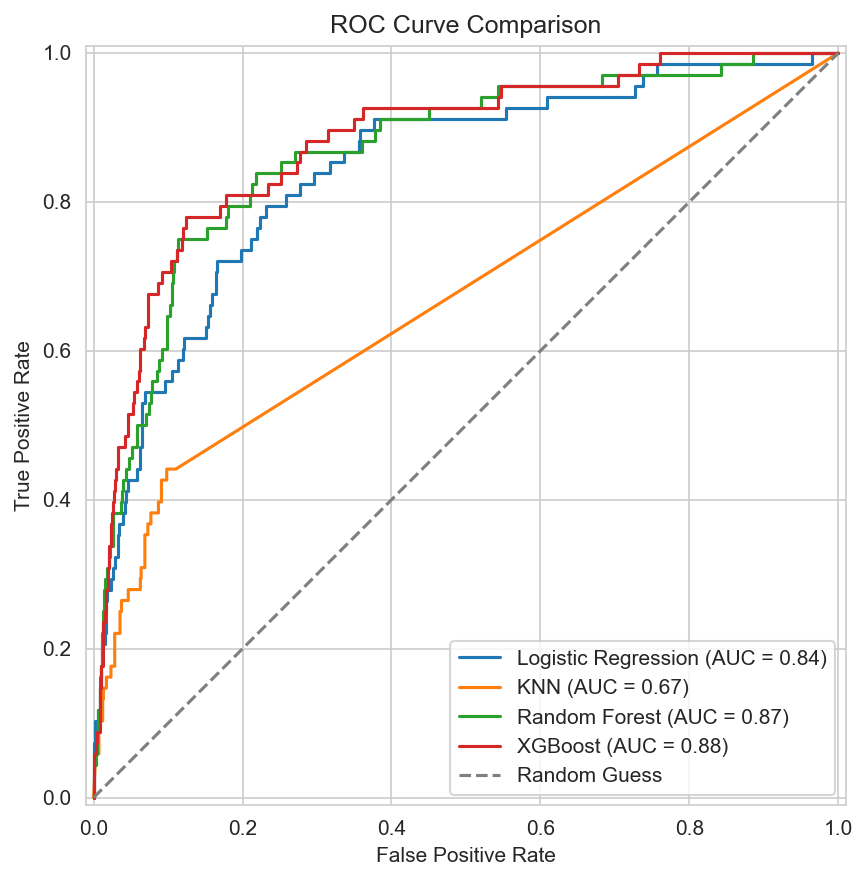

In [28]:
display(Image(ev.plot_roc_curves(tuned_fitted, X_test, y_test, filename="roc_curves.png")))

## 21. Confusion Matrix Comparison

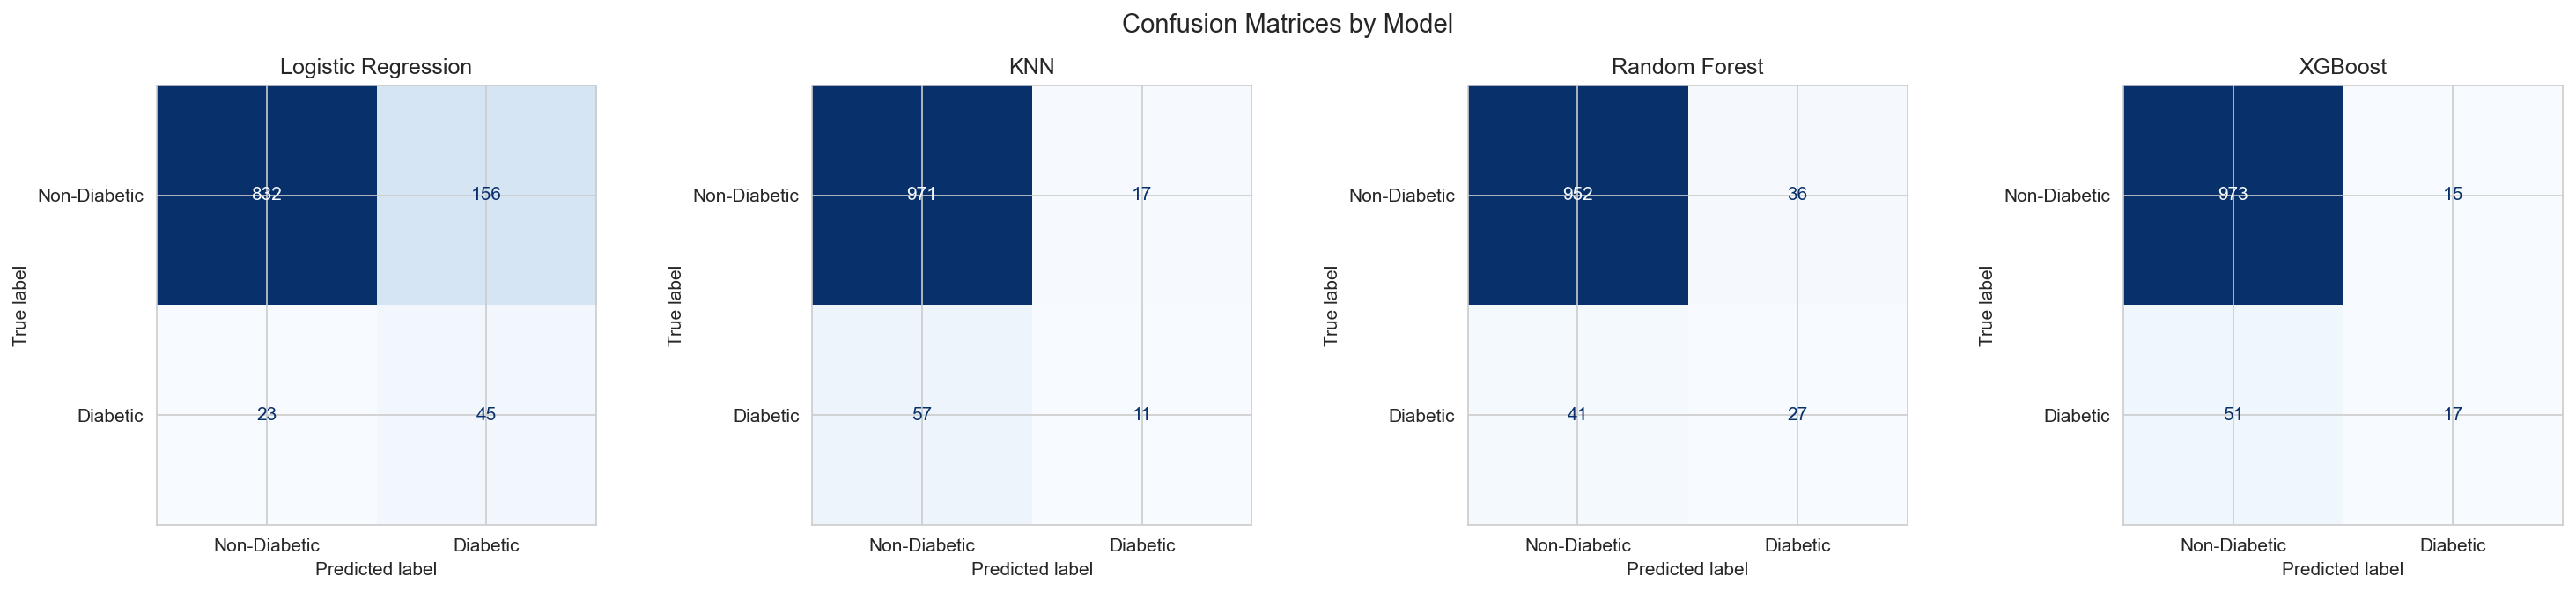

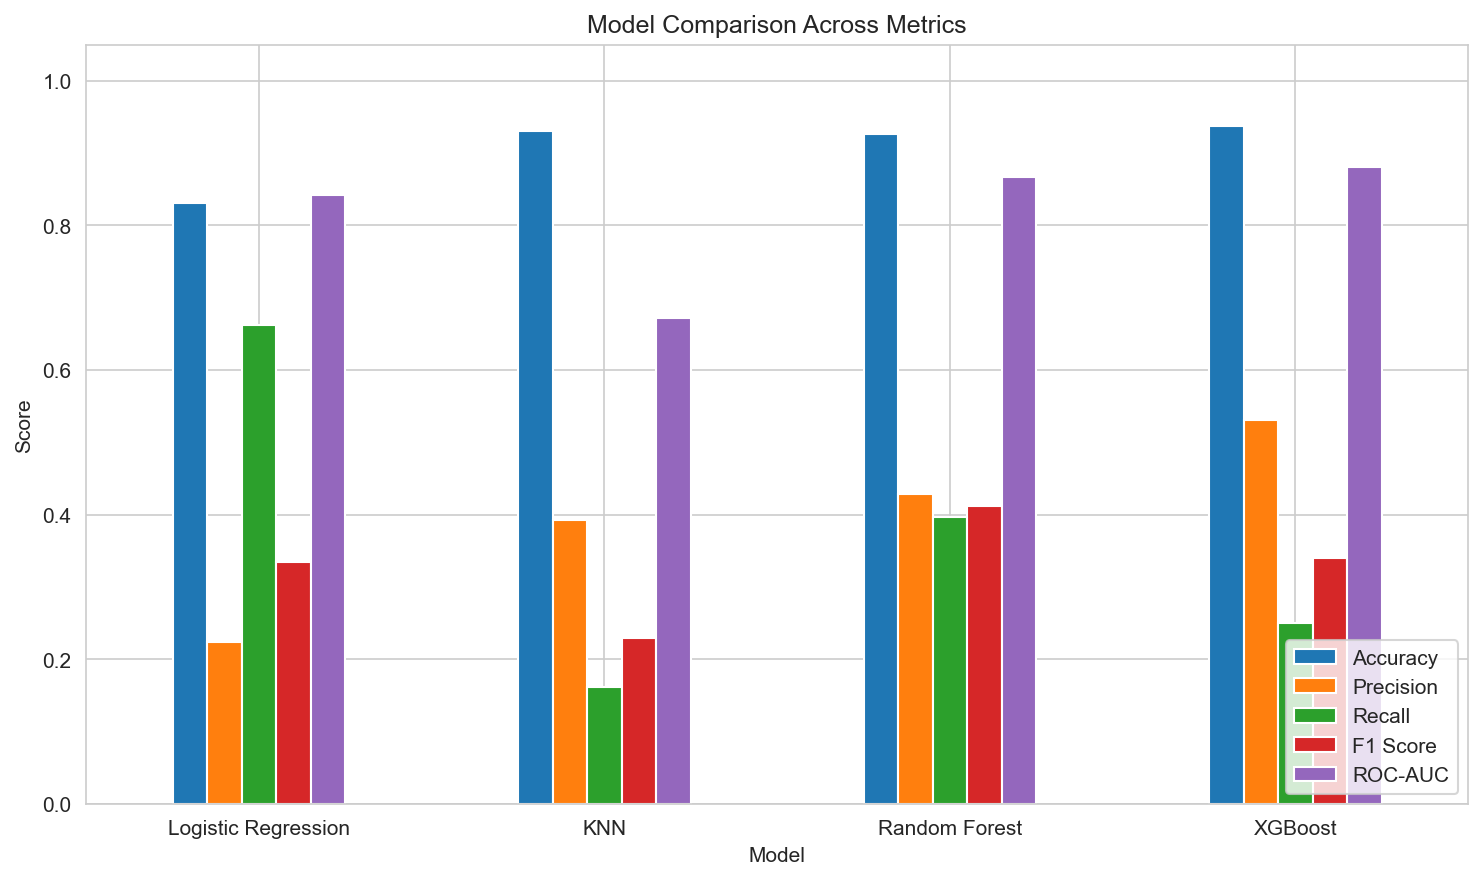

In [29]:
display(Image(ev.plot_confusion_matrices(tuned_fitted, X_test, y_test, filename="confusion_matrices_tuned.png")))
display(Image(ev.plot_model_comparison_bar(tuned_results, filename="model_comparison.png")))

## 22. Feature Importance

We report which features each model relies on most for its predictions. **This shows association with model predictions, not medical causation** — we do not claim any feature "causes" diabetes.

In [30]:
lr_importance = ev.get_logistic_regression_importance(tuned_fitted["Logistic Regression"])
rf_importance = ev.get_tree_importance(tuned_fitted["Random Forest"])
xgb_importance = ev.get_tree_importance(tuned_fitted["XGBoost"])

print("Logistic Regression - top 10 by |standardized coefficient|:")
display(lr_importance.head(10))
print("\
Random Forest - top 10 by importance:")
display(rf_importance.head(10))
print("\
XGBoost - top 10 by importance:")
display(xgb_importance.head(10))

Logistic Regression - top 10 by |standardized coefficient|:


,Feature,Coefficient,Abs_Coefficient
0,flags__hypertensive,2.260092,2.260092
1,flags__family_hypertension,2.109622,2.109622
2,flags__family_diabetes,-2.075361,2.075361
3,num__bmi,1.252630,1.252630
4,flags__cardiovascular_disease,0.855328,0.855328
5,num__weight,-0.817364,0.817364
6,num__height,0.777240,0.777240
7,num__glucose,0.707818,0.707818
8,flags__stroke,-0.618726,0.618726
9,num__diastolic_bp,0.232913,0.232913


Random Forest - top 10 by importance:


,Feature,Importance
0,num__glucose,0.230773
1,flags__hypertensive,0.175209
2,num__systolic_bp,0.112590
3,num__diastolic_bp,0.092702
4,num__weight,0.089772
5,num__bmi,0.085633
6,num__age,0.074794
7,num__pulse_rate,0.068276
8,num__height,0.055401
9,gender__gender_Male,0.008332


XGBoost - top 10 by importance:


,Feature,Importance
0,flags__hypertensive,0.473667
1,num__glucose,0.103087
2,num__diastolic_bp,0.045827
3,num__age,0.045493
4,num__systolic_bp,0.044245
5,num__bmi,0.042908
6,num__weight,0.042447
7,flags__cardiovascular_disease,0.042334
8,num__height,0.040815
9,num__pulse_rate,0.039551


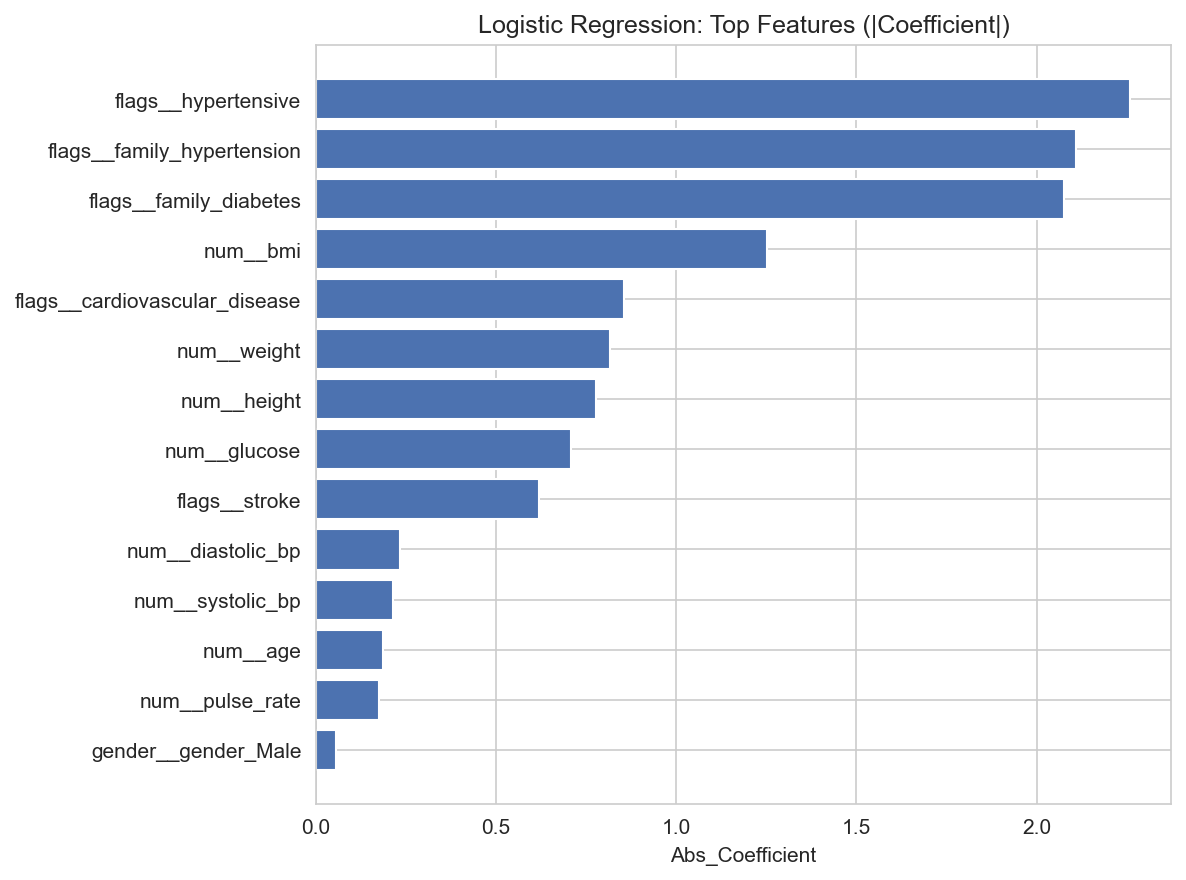

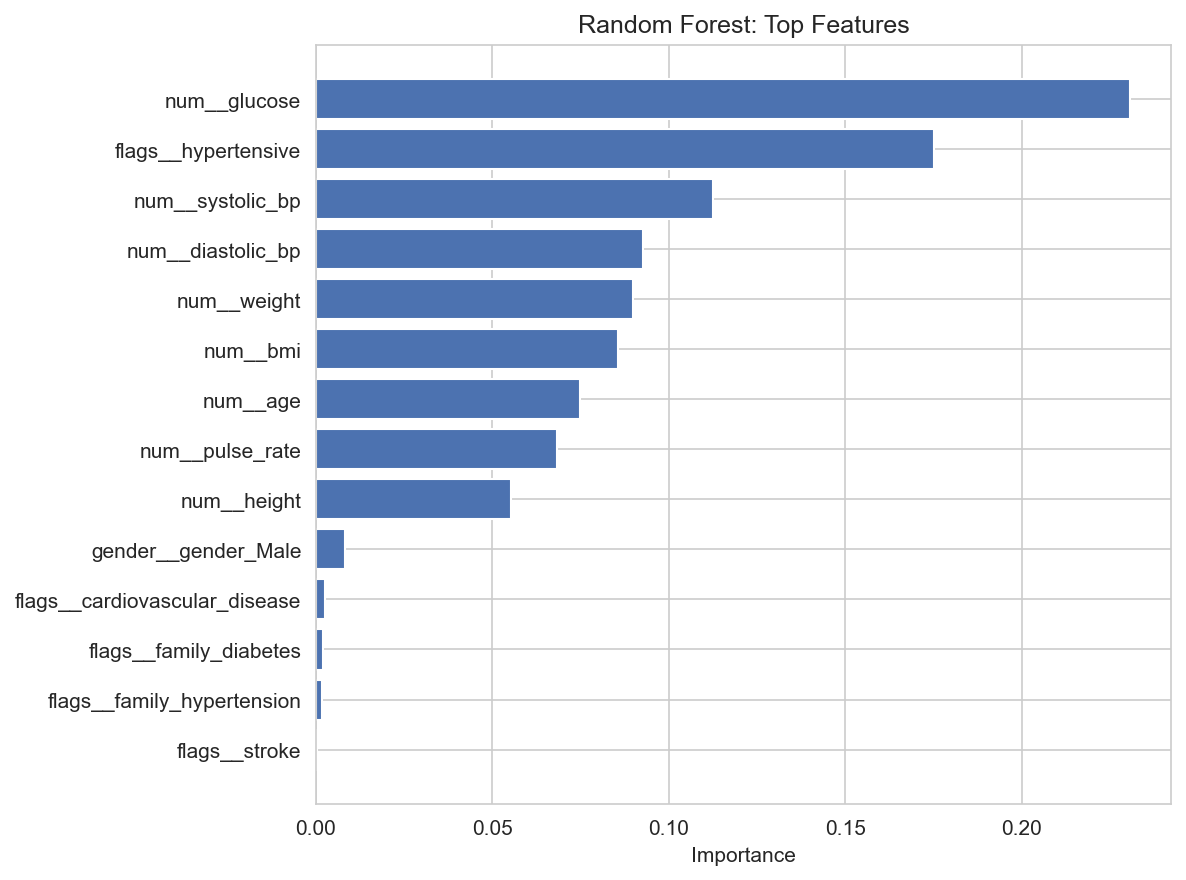

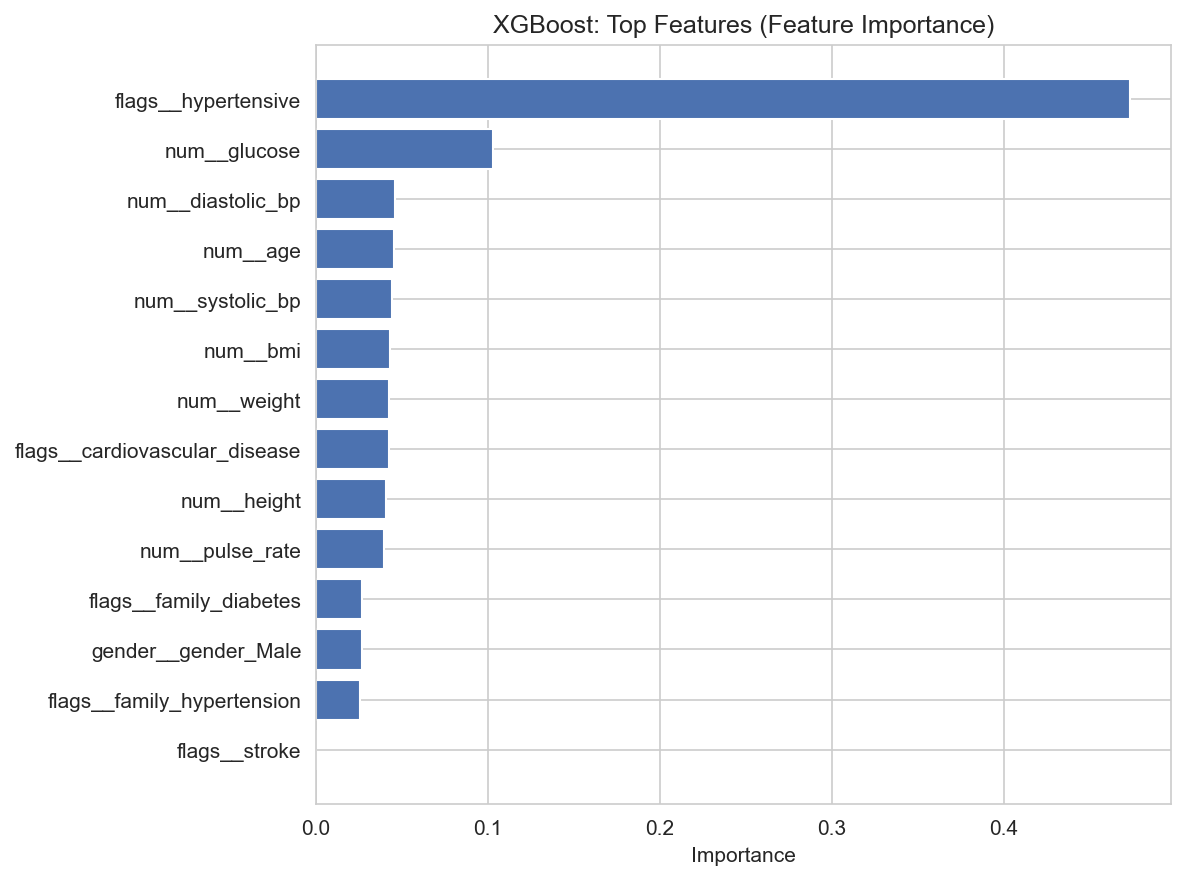

In [31]:
display(Image(ev.plot_feature_importance(lr_importance, "Abs_Coefficient", "Logistic Regression: Top Features (|Coefficient|)", "feature_importance_logreg.png")))
display(Image(ev.plot_feature_importance(rf_importance, "Importance", "Random Forest: Top Features", "feature_importance_rf.png")))
display(Image(ev.plot_feature_importance(xgb_importance, "Importance", "XGBoost: Top Features (Feature Importance)", "feature_importance.png")))

**Finding:** `hypertensive` status is the single most consistently influential feature — ranked #1 in Logistic Regression and XGBoost, and #2 in Random Forest. This is directly consistent with the EDA finding in Section 6 that diabetes prevalence is about 9x higher among hypertensive patients (31.3%) than non-hypertensive patients (3.4%). `glucose` is the top feature for Random Forest and the #2 feature for XGBoost, but drops to #8 for Logistic Regression — likely because its linear signal is split across several correlated numerical features (`bmi`, `weight`, `height` all rank above it for Logistic Regression) once everything is standardized, an effect tree-based models are less prone to since each split simply picks whichever single feature separates the classes best at that node. All three models pick these features up as **associated with**, not necessarily causing, diabetes status.

## 23. Discussion

**Which model performed best?** There is no single "best" model independent of use case:
- **Best recall (fewest missed diabetic patients):** Logistic Regression, 66.2% — more than 1.6x any other tuned model. Best choice for a first-pass screening tool where a false positive only costs a follow-up test.
- **Best F1-score (balanced precision/recall):** Random Forest, 0.412.
- **Best ROC-AUC (best overall ranking quality):** XGBoost, 0.881.
- **Best precision:** XGBoost, 53.1% — but at only 25.0% recall, so a large share of diabetic patients would still be missed if precision were prioritized on its own.
- **KNN was consistently the weakest model** on every imbalance-sensitive metric — it has no built-in class-weighting mechanism, and even after tuning its recall (16.2%) and F1 (0.229) were the lowest of all four tuned models; its SMOTE variant (54.4% recall) was a real improvement but still trailed the tree-based models on F1 and precision.

**Did balancing improve minority-class prediction?** Mostly yes — class weighting and/or SMOTE improved diabetic-class recall for Logistic Regression, KNN, and XGBoost relative to their unweighted baselines (Section 16). The exception was Random Forest under plain class weighting alone, whose recall actually fell (16.2% -> 11.8%); Random Forest only benefited from imbalance handling once tuned jointly with its other hyperparameters (Section 18-19).

**Did tuning improve results?** Mixed — and this dataset's tuning results carry a genuine lesson about overfitting to cross-validation folds. Tuning clearly improved Random Forest's test F1 (0.253 -> 0.412) and recall (16.2% -> 39.7%). But **XGBoost's test F1 actually got *worse* after tuning (0.396 -> 0.340)**, even though the chosen configuration had the best cross-validated F1 (0.415) among the non-Random-Forest candidates — it generalized less well to the held-out test set than XGBoost's untuned defaults did. **KNN's tuned ROC-AUC (0.672) was also worse than its untuned baseline (0.703)**, for a similar reason: cross-validation picked `n_neighbors=3` to maximize F1 on the training folds, a high-variance choice that didn't transfer as cleanly to ROC-AUC on the test set. Together, these two results show that optimizing a metric via cross-validation does not guarantee improvement on that same metric — or on a different metric — on genuinely held-out data.

**Possible signs of overfitting:** Random Forest's tuned configuration (`max_depth=30`, `min_samples_leaf=4`) allows fairly deep, expressive trees, yet its test ROC-AUC (0.868) stayed close to its baseline (0.869), suggesting this did not meaningfully harm generalization. XGBoost's test-F1 regression above is the clearer example of a metric-driven overfitting effect in this project: its cross-validated F1 (0.415) overstated how well the chosen hyperparameters would actually generalize.

**Do simpler models perform competitively?** Partially. Logistic Regression, the simplest model compared, achieved by far the highest recall of any tuned model, but its ROC-AUC (0.843) trailed both tree-based ensembles (0.868-0.881) by a noticeable margin, suggesting the relationship between these clinical features and diabetes status is not purely linear.

## 24. Limitations

- **Severe class imbalance** (6.5% diabetic): even the best recall achieved (66.2%) still misses roughly a third of diabetic patients, and all models' precision remains low (22-53%).
- **Single-country, single-dataset sample:** findings reflect one Bangladeshi clinical population and may not generalize elsewhere without external validation.
- **Predictions are not clinical diagnoses** — this is a coursework comparative-analysis exercise, not a diagnostic tool.
- **Limited feature set:** the dataset lacks some known diabetes risk factors (diet, physical activity, HbA1c, waist circumference), which likely constrains achievable performance.
- **A small subgroup anomaly** was observed for `family_diabetes` (Section 6) — the `family_diabetes=1` subgroup is small (169 patients) and should not be over-interpreted as evidence that family history is protective.
- **Tuned results can regress relative to cross-validation** (Section 23) — XGBoost's and KNN's tuning outcomes are a concrete reminder that CV performance is an estimate, not a guarantee, especially with a minority class this small (~340 positive cases split across 5 folds).
- **Model generalizability requires external validation** on an independent dataset before these findings should be treated as robust beyond this specific sample and train/test split.

## 25. Conclusion

This notebook compared Logistic Regression, KNN, Random Forest, and XGBoost for diabetes risk classification on the DiaBD Bangladesh dataset, with a specific focus on the dataset's severe class imbalance (6.5% diabetic). Baseline models achieved misleadingly high accuracy (93.8-94.0%) while catching relatively few diabetic patients (14.7-30.9% recall), directly demonstrating why accuracy alone is inappropriate here. Class weighting and SMOTE meaningfully improved diabetic-class recall for most models, though Random Forest needed full hyperparameter tuning — not class weighting alone — to actually benefit. After tuning, no single algorithm dominated every metric: **Random Forest offered the best precision/recall balance (F1 = 0.412)**, **XGBoost offered the best overall ranking ability (ROC-AUC = 0.881)**, and **Logistic Regression offered by far the highest diabetic-class recall (66.2%)** at the cost of precision. `hypertensive` status was the single most consistently important predictor across all interpretable models, and `glucose` was a close second for the two tree-based models — findings directly grounded in, and consistent with, the underlying data. Tuning did not universally help: XGBoost's and KNN's test performance each regressed on at least one metric relative to their untuned baselines, a useful reminder that cross-validated hyperparameter search optimizes an *estimate* of generalization, not generalization itself. **Model selection for this task should be driven by the intended screening use case (favoring recall vs. favoring precision/balance/ranking quality) rather than by accuracy or by picking a single "winner" algorithm.**

See `report/final_report.md` for the full academic write-up, including future work directions.